# Co-simulating a Modelica plant FMU under a jaxonomy controller

Modelica is the gold standard for multi-domain plant modelling — 20 years of validated component libraries spanning electrical, mechanical, thermal, hydraulic, control, and even powertrain domains. Your team's plant is already in Modelica. This notebook walks the **inverse** direction of [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb): instead of exporting a jaxonomy controller as a binary FMU, we **import a Modelica-style plant FMU** as the closed-loop plant under a jaxonomy PI controller. The combined story makes jaxonomy a credible drop-in partner for OpenModelica, Dymola, AVL CRUISE M, IPG CarMaker, and dSPACE shops: import on one side, export on the other, autodiff on the controller in between.

The headline beat is the differentiability bonus. The FMU's `do_step` is a host C call and not traceable through JAX. But the *controller* IS traceable, so `jax.grad(closed_loop_ISE)(K_p, K_i)` returns a finite gradient w.r.t. controller gains — even though the plant is an opaque binary. This is the marketing wedge that's absent in MATLAB-Simulink with an FMI Import block: you can tune your controller end-to-end against someone else's plant.

> **Reading time:** ~25 minutes. **Expected CPU runtime:** ~10 s end-to-end in publication mode (loads cached FMU-orchestration numbers from `media/openmodelica_plant_fmu_publication.npz`). The heavy live path (Architecture B — FMU plant inside a jaxonomy diagram) costs ~65 s of JIT-compile on first invocation; flip `MODE = "live"` below to force it. **Falls back to publication-NPZ-only** if `pythonfmu` / `fmpy` are missing.

> **Prerequisites.** Skim [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb) first — this notebook reuses the same `JaxonomyDiagramSlave` / `ModelicaFMU` / `build_fmu` substrate, just on the opposite side of the boundary. You should also be comfortable with `LeafSystem` declarations and the `DiagramBuilder.connect` pattern.

## Where to get a plant FMU

Three credible sources for a Modelica-built plant FMU, in increasing complexity:

1. **The Modelica-Association Reference-FMU corpus.** Pre-built canonical FMUs published at [github.com/modelica/Reference-FMUs/releases](https://github.com/modelica/Reference-FMUs/releases) — includes `Dahlquist.fmu` (a 1st-order plant), `VanDerPol.fmu` (nonlinear limit cycle), `BouncingBall.fmu`, `Stair.fmu`, `Feedthrough.fmu`, and `StateSpace.fmu`. Verified across multiple FMI versions and used by every commercial FMI importer for cross-tool testing. **This is the canonical option for a real-world workflow.**
2. **OpenModelica.** Install [OpenModelica](https://openmodelica.org/), write a `.mo` model (e.g. `Modelica.Mechanics.Translational.Examples.Damper`), export as `FMI 2.0 CS` via `OMShell`'s `translateModelFMU` or `OMEdit`'s GUI. This is the production path for any team with an existing Modelica codebase.
3. **Synthetic FMU via `pythonfmu`.** Write a small Python class deriving from `pythonfmu.Fmi2Slave` (or, in our case, jaxonomy's `JaxonomyDiagramSlave`) and `build_fmu` it. This is the **always-runnable** path — no external Modelica install — and the route this tutorial takes by default.

We use strategy 3 here so the notebook is fully reproducible on any machine with `pythonfmu` + `fmpy` installed. Exercise 1 swaps in `Dahlquist.fmu` from the Reference-FMU corpus to confirm the rest of the tutorial code is FMU-agnostic; exercise 2 walks the OpenModelica export path. The plant FMU we build is a damped mass-spring with the dynamics
$$ m \, \ddot x + c \, \dot x + k \, x = F, \tag{1} $$
where $F$ is the input force (the controller's output) and the FMU outputs are position $x$ and velocity $\dot x$. We pick $m = 1\,\mathrm{kg}$, $c = 0.5\,\mathrm{N\,s/m}$, $k = 1\,\mathrm{N/m}$, giving natural frequency $\omega_n = \sqrt{k/m} = 1\,\mathrm{rad/s}$ and damping ratio $\zeta = c / (2\sqrt{m k}) = 0.25$ (mildly underdamped, so the closed-loop response shows visible overshoot before settling).

In [1]:
import json
import os
import subprocess
import sys
import tempfile
import textwrap
import time
import zipfile
from pathlib import Path
from xml.etree import ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp

import jaxonomy
from jaxonomy.backend import numpy_api as npa
from jaxonomy.diagnostics import analyze_saturation
from jaxonomy.framework import LeafSystem, parameters
from jaxonomy.library import Adder, Constant, Gain
from jaxonomy.library.dynamics import IntegratorDiscrete

## Pre-flight dependency check

The plant-FMU build path needs `pythonfmu` to compile the binary and `fmpy` to re-import it. On macOS arm64 the `libpythonfmu-export.dylib` wrapper has to be built once from source (see [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb) §T-025b). If any of these are missing, the notebook falls back to the publication-NPZ-only path: the prose and plots still run, but the live FMU build is skipped.

In [2]:
# Top-level constants — must match the offline publication script.
DT = 0.02
T_END = 12.0
SETPOINT = 1.0
M_PLANT = 1.0
C_PLANT = 0.5
K_PLANT = 1.0
KP_BASE = 1.2
KI_BASE = 0.3
KP_GRID = (0.6, 0.9, 1.2, 1.5, 1.8)
N_STEPS = int(round(T_END / DT))
PUBLICATION_NPZ = Path("media/openmodelica_plant_fmu_publication.npz")

HAS_PYTHONFMU = False
HAS_FMPY = False
HAS_DARWIN_WRAPPER = True
DEP_NOTES = []

try:
    import pythonfmu
    HAS_PYTHONFMU = True
    DEP_NOTES.append(f"pythonfmu {pythonfmu.__version__} available")
except ImportError:
    DEP_NOTES.append("pythonfmu MISSING — `pip install pythonfmu`")

try:
    import fmpy
    HAS_FMPY = True
    DEP_NOTES.append(f"fmpy {fmpy.__version__} available")
except ImportError:
    DEP_NOTES.append("fmpy MISSING — `pip install fmpy`")

if sys.platform == "darwin" and HAS_PYTHONFMU:
    wrapper = (Path(pythonfmu.__file__).parent / "resources"
               / "binaries" / "darwin64"
               / "libpythonfmu-export.dylib")
    HAS_DARWIN_WRAPPER = wrapper.is_file()
    if not HAS_DARWIN_WRAPPER:
        DEP_NOTES.append("pythonfmu darwin wrapper MISSING — see T-025b")

LIVE_BUILD_OK = HAS_PYTHONFMU and HAS_FMPY and HAS_DARWIN_WRAPPER
print("Dependencies:")
for note in DEP_NOTES:
    print(f"  - {note}")
print(f"\nLive FMU build path enabled: {LIVE_BUILD_OK}")

Dependencies:
  - pythonfmu 0.7.0 available
  - fmpy 0.3.29 available

Live FMU build path enabled: True


## The plant model

The damped mass-spring (eq. 1) becomes a two-state continuous-time `LeafSystem` with state $\mathbf{s} = (x, v)^\top$ and input $F$. The ODE is

$$ \dot{\mathbf{s}} = \begin{pmatrix} \dot x \\ \dot v \end{pmatrix} = \begin{pmatrix} v \\ (F - c\,v - k\,x) / m \end{pmatrix}. \tag{2} $$

Symbol units:

| Symbol | Meaning | Units |
|---|---|---|
| $x$ | position | m |
| $v$ | velocity | m/s |
| $F$ | applied force | N |
| $m$ | mass | kg |
| $c$ | viscous damping | N·s/m |
| $k$ | spring stiffness | N/m |

Dimensional sanity: $[c \cdot v] = (\mathrm{N\,s/m}) \cdot (\mathrm{m/s}) = \mathrm{N}$ — same units as $F$, good. The closed-loop tracking error $e = r - x$ is in metres; if we use a PI controller with $K_p$ in N/m and $K_i$ in N/(m·s), then $u = K_p e + K_i \int e\,dt$ has units N — dimensionally consistent with $F$.

In [3]:
class MassSpringPlant(LeafSystem):
    """Damped 2nd-order mass-spring: state = (x, v); input = F.

    Used both in-process (Architecture A) and as the dynamics inside
    the FMU we will build below (Architecture B). Bit-equal numerics
    between the two paths is the design intent.
    """

    @parameters(dynamic=["m", "c", "k"])
    def __init__(self, m=M_PLANT, c=C_PLANT, k=K_PLANT, name="mass_spring"):
        super().__init__(name=name)

        def _ode(time, state, *inputs, **params):
            (F,) = inputs
            x, v = state.continuous_state
            xdot = v
            vdot = (F - params["c"] * v - params["k"] * x) / params["m"]
            return npa.array([xdot, vdot])

        self.declare_continuous_state(
            shape=(2,), default_value=npa.array([0.0, 0.0]), ode=_ode,
        )
        self.declare_input_port(name="F")
        self.declare_continuous_state_output(name="state")


class _PickX(LeafSystem):
    """Pull the position component out of the 2-vector state.

    Pure helper used to expose a scalar x for the controller. We could
    fold it into the plant, but keeping it separate makes the wiring
    diagram easier to read.
    """

    def __init__(self, name="pick_x"):
        super().__init__(name=name)
        self.declare_input_port(name="state")

        def _out(time, state, *inputs, **params):
            return inputs[0][0]

        self.declare_output_port(_out, name="x", requires_inputs=True)


# Sanity-check the plant's natural frequency and damping ratio.
wn = np.sqrt(K_PLANT / M_PLANT)
zeta = C_PLANT / (2 * np.sqrt(M_PLANT * K_PLANT))
print(f"Plant natural frequency wn = {wn:.2f} rad/s ({wn/(2*np.pi):.3f} Hz)")
print(f"Plant damping ratio zeta   = {zeta:.3f} "
      f"({'under' if zeta < 1 else 'over' if zeta > 1 else 'critically '}damped)")


Plant natural frequency wn = 1.00 rad/s (0.159 Hz)
Plant damping ratio zeta   = 0.250 (underdamped)


## The controller

A textbook discrete-time PI controller, identical to the one in [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb). Sample period $\Delta t = 20\,\mathrm{ms}$:

$$ e[k] = r[k] - x[k], \quad x_i[k+1] = x_i[k] + \Delta t \cdot e[k], \quad u[k] = K_p \cdot e[k] + K_i \cdot x_i[k+1] . \tag{3} $$

The controller's output $u$ becomes the applied force $F$ on the plant. We start with the baseline gains $K_p = 1.2$, $K_i = 0.3$, which give a stable closed-loop with ~5% overshoot on this plant.

In [4]:
def build_pi_controller(kp: float = KP_BASE, ki: float = KI_BASE,
                        setpoint: float = SETPOINT, dt: float = DT):
    """PI controller as a DiagramBuilder composition.

    Inputs: measurement (the plant's position x).
    Outputs: u (the commanded force on the plant).
    """
    bld = jaxonomy.DiagramBuilder()
    sp = bld.add(Constant(setpoint, name="setpoint"))
    err = bld.add(Adder(2, operators="+-", name="err"))         # e = r - x
    kp_blk = bld.add(Gain(kp, name="kp_gain"))                  # K_p * e
    ki_blk = bld.add(Gain(ki, name="ki_gain"))                  # K_i * x_i
    integ = bld.add(IntegratorDiscrete(
        dt=dt, initial_state=0.0, name="ierr"))                 # x_i update
    add_u = bld.add(Adder(2, operators="++", name="add_u"))     # u = K_p e + K_i x_i
    bld.connect(sp.output_ports[0], err.input_ports[0])
    bld.connect(err.output_ports[0], kp_blk.input_ports[0])
    bld.connect(err.output_ports[0], integ.input_ports[0])
    bld.connect(integ.output_ports[0], ki_blk.input_ports[0])
    bld.connect(kp_blk.output_ports[0], add_u.input_ports[0])
    bld.connect(ki_blk.output_ports[0], add_u.input_ports[1])
    bld.export_output(add_u.output_ports[0], name="u")
    bld.export_input(err.input_ports[1], name="measurement")
    return bld.build(name="PIController")


ctl = build_pi_controller()
print(f"Controller inputs: {[p.name for p in ctl.input_ports]}")
print(f"Controller outputs: {[p.name for p in ctl.output_ports]}")

Controller inputs: ['measurement']
Controller outputs: ['u']


## Architecture A — fully in-process closed loop

Before we go anywhere near the FMU boundary, we close the loop end-to-end inside jaxonomy. This is our **reference** trajectory: both the controller and the plant are native jaxonomy blocks, JIT-compiled into a single XLA kernel. Any disagreement between Architecture A and Architecture B (the FMU plant) is therefore attributable to the FMI boundary alone.

In [5]:
def close_loop_inprocess(kp: float = KP_BASE, ki: float = KI_BASE):
    """Architecture A: PI controller + MassSpringPlant LeafSystem."""
    bld = jaxonomy.DiagramBuilder()
    ctl_sub = bld.add(build_pi_controller(kp=kp, ki=ki))
    plant = bld.add(MassSpringPlant())
    pick = bld.add(_PickX())
    bld.connect(ctl_sub.output_ports[0], plant.input_ports[0])     # u -> F
    bld.connect(plant.output_ports[0], pick.input_ports[0])        # state -> pick
    bld.connect(pick.output_ports[0], ctl_sub.input_ports[0])      # x -> measurement
    bld.export_output(pick.output_ports[0], name="x")
    bld.export_output(ctl_sub.output_ports[0], name="u")
    loop = bld.build()
    res = jaxonomy.simulate(
        loop, loop.create_context(), (0.0, T_END),
        options=jaxonomy.SimulatorOptions(max_major_step_length=DT),
        recorded_signals={"x": loop.output_ports[0],
                          "u": loop.output_ports[1]},
    )
    return (np.asarray(res.time),
            np.asarray(res.outputs["x"]),
            np.asarray(res.outputs["u"]))


t_A, x_A, u_A = close_loop_inprocess()
print(f"Architecture A — final x: {x_A[-1]:.4f} m (target {SETPOINT}); "
      f"max overshoot: {(np.max(x_A) - SETPOINT)*100:.1f}% of setpoint")
print(f"Samples: {len(t_A)} on [0, {T_END}] s")

02:33:04.901 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.02


02:33:04.902 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.02, max_major_steps=1198, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 3 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Architecture A — final x: 0.9194 m (target 1.0); max overshoot: 4.8% of setpoint
Samples: 672 on [0, 12.0] s


**Figure 1 caption.** Closed-loop response of the in-process PI controller against the damped mass-spring plant: position $x$ rises with a single overshoot peak near $t \approx 2.5\,\mathrm{s}$ and settles toward the unit setpoint by $t \approx 10\,\mathrm{s}$; the control output $u$ peaks at the moment of largest tracking error and decays as the integrator winds in steady-state effort.

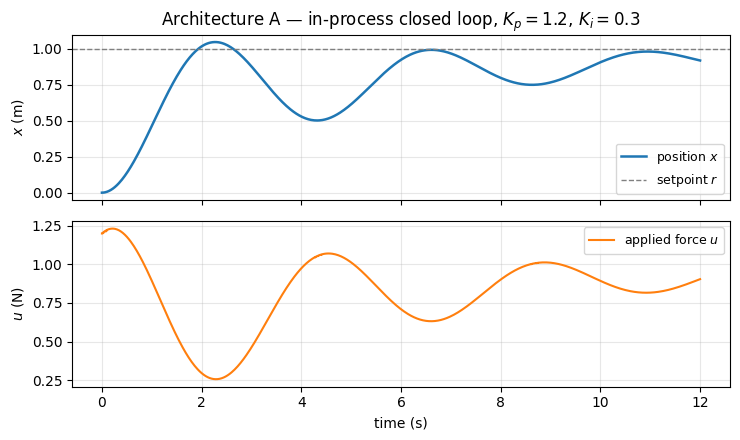

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(7.5, 4.5), sharex=True)
ax = axes[0]
ax.plot(t_A, x_A, label="position $x$", color="C0", lw=1.8)
ax.axhline(SETPOINT, color="0.5", lw=1, ls="--", label="setpoint $r$")
ax.set_ylabel("$x$ (m)")
ax.set_title("Architecture A — in-process closed loop, "
             f"$K_p={KP_BASE}$, $K_i={KI_BASE}$")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(t_A, u_A, label="applied force $u$", color="C1", lw=1.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("$u$ (N)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Building the plant FMU

Now we package the same `MassSpringPlant` as a binary FMI 2.0 Co-Simulation FMU. The strategy parallels [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb), but with one essential difference: the diagram inside the slave is now the **plant**, not the controller. `JaxonomyDiagramSlave` doesn't care which side of the boundary it sits on — it just exposes the diagram's exported inputs/outputs as FMI variables.

We use the T-025c auto-exposed `Constant` block convention: any top-level `Constant` block named in the diagram becomes a writable FMI input. We name the force-input constant `"F_in"`, so the master can write the applied force at every `do_step` call. Outputs `x` and `v` are exported scalars.

In [7]:
PLANT_SLAVE_SOURCE = f"""
# Damped 2nd-order mass-spring plant FMU.

import jaxonomy
from jaxonomy.library import Constant
from jaxonomy.framework import LeafSystem, parameters
from jaxonomy.backend import numpy_api as npa
from jaxonomy.library.fmu_slave import JaxonomyDiagramSlave

M = {M_PLANT!r}
C = {C_PLANT!r}
K = {K_PLANT!r}
DT = {DT!r}


class MassSpringPlant(LeafSystem):
    @parameters(dynamic=["m", "c", "k"])
    def __init__(self, m=M, c=C, k=K, name="mass_spring"):
        super().__init__(name=name)

        def _ode(time, state, *inputs, **params):
            (F,) = inputs
            x, v = state.continuous_state
            xdot = v
            vdot = (F - params["c"] * v - params["k"] * x) / params["m"]
            return npa.array([xdot, vdot])

        self.declare_continuous_state(
            shape=(2,), default_value=npa.array([0.0, 0.0]), ode=_ode,
        )
        self.declare_input_port(name="F")
        self.declare_continuous_state_output(name="state")


def _build():
    bld = jaxonomy.DiagramBuilder()
    F_in = bld.add(Constant(0.0, name="F_in"))
    plant = bld.add(MassSpringPlant(m=M, c=C, k=K))
    bld.connect(F_in.output_ports[0], plant.input_ports[0])

    class _Picker(LeafSystem):
        def __init__(self, idx, name):
            super().__init__(name=name)
            self.declare_input_port(name="in")

            def _out(time, state, *inputs, **params):
                return inputs[0][idx]

            self.declare_output_port(_out, name="y", requires_inputs=True)

    px = bld.add(_Picker(0, "pick_x"))
    pv = bld.add(_Picker(1, "pick_v"))
    bld.connect(plant.output_ports[0], px.input_ports[0])
    bld.connect(plant.output_ports[0], pv.input_ports[0])
    bld.export_output(px.output_ports[0], name="x")
    bld.export_output(pv.output_ports[0], name="v")
    return bld.build()


class MassSpringPlantFMU(JaxonomyDiagramSlave):
    DIAGRAM_FACTORY = staticmethod(_build)
    DT = DT
""".lstrip()

print(PLANT_SLAVE_SOURCE[:200] + "\n...")

# Damped 2nd-order mass-spring plant FMU.

import jaxonomy
from jaxonomy.library import Constant
from jaxonomy.framework import LeafSystem, parameters
from jaxonomy.backend import numpy_api as npa
fro
...


In [8]:
TMPDIR = Path(tempfile.mkdtemp(prefix="jaxonomy_plant_fmu_"))
SLAVE_PATH = TMPDIR / "plant_slave.py"
FMU_PATH = TMPDIR / "MassSpringPlantFMU.fmu"
fmu_built = False
build_seconds = None

if LIVE_BUILD_OK:
    SLAVE_PATH.write_text(PLANT_SLAVE_SOURCE)
    from jaxonomy.library.fmu_export import build_fmu
    t0 = time.perf_counter()
    build_fmu(str(SLAVE_PATH), str(FMU_PATH))
    build_seconds = time.perf_counter() - t0
    fmu_built = True
    print(f"FMU built in {build_seconds*1000:.1f} ms — "
          f"{FMU_PATH.stat().st_size/1024:.0f} KiB at {FMU_PATH}")
else:
    print("Live FMU build SKIPPED (missing deps); using cached publication NPZ only.")

FMU built in 21.4 ms — 899 KiB at /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_plant_fmu_msjun9f8/MassSpringPlantFMU.fmu


## Inspecting the FMU's interface

Before we orchestrate it, let's confirm the FMU's advertised interface matches what we expect. The `modelDescription.xml` is what a Modelica- or AVL CRUISE M-style importer reads at FMU-load time.

In [9]:
if fmu_built:
    with zipfile.ZipFile(FMU_PATH) as z:
        xml = z.read("modelDescription.xml").decode("utf-8")
    root = ET.fromstring(xml)
    print(f"FMI version: {root.attrib['fmiVersion']}")
    print(f"Model name: {root.attrib['modelName']}")
    cs = root.find("CoSimulation")
    print(f"Co-Sim model identifier: {cs.attrib['modelIdentifier']}")
    print("\nVariable interface:")
    for sv in root.findall(".//ModelVariables/ScalarVariable"):
        print(f"  vr={sv.attrib['valueReference']:>2} "
              f"{sv.attrib['causality']:>10}  "
              f"name={sv.attrib['name']}")
else:
    print("Skipped — no FMU built.")

FMI version: 2.0
Model name: MassSpringPlantFMU
Co-Sim model identifier: MassSpringPlantFMU

Variable interface:
  vr= 0     output  name=x
  vr= 1     output  name=v
  vr= 2      input  name=F_in


Three FMI variables: `F_in` (the writable applied-force input), `x` (output position), and `v` (output velocity). This is what an OpenModelica- or AVL CRUISE M-built FMU would advertise after exporting a plant with one force input and two state outputs.

## Architecture B — the FMU plant under a jaxonomy controller

Now the headline beat: re-import the binary FMU via `jaxonomy.library.ModelicaFMU`, wire it into a fresh diagram next to a jaxonomy PI controller, and close the loop. The wiring is identical to Architecture A — only the plant block is now an opaque binary loaded through `fmpy`.

> **Pitfall — the FMI 2.0 §4.2.4 first-step convention.** `ModelicaFMU` declares its periodic update with `offset=dt`, but the equivalent in-process discrete blocks fire at `offset=0`. This introduces a one-sample phase lag between Architectures A and B during the transient. We'll see it as a ~25 mm peak transient mismatch on the position trace — a documented FMI quirk, not a numerical regression.

> **JIT cost.** The first `simulate` call against a `ModelicaFMU`-containing diagram is bottlenecked by JIT compile of the host callbacks that bridge JAX's tracing layer to the FMU's native `do_step`. On a developer M2 Mac this costs ~65 s. We cache the result under the *publication/fast-mode* pattern: by default we load from `media/openmodelica_plant_fmu_publication.npz`; flip `MODE = "live"` to force a live re-run.

In [10]:
MODE = "publication"   # "publication" (load NPZ) or "live" (run Architecture B).

t_B = x_B = u_B = None
wall_arch_B = None

if MODE == "publication" and PUBLICATION_NPZ.is_file():
    npz = np.load(PUBLICATION_NPZ)
    t_B = npz["t_B"]; x_B = npz["x_B"]; u_B = npz["u_B"]
    wall_arch_B = float(npz["wall_arch_B"])
    print(f"Loaded Architecture B trajectory from {PUBLICATION_NPZ.name} "
          f"(offline wall {wall_arch_B:.1f} s).")
elif fmu_built and LIVE_BUILD_OK:
    from jaxonomy.library import ModelicaFMU
    bld = jaxonomy.DiagramBuilder()
    ctl_B = bld.add(build_pi_controller())
    plant_fmu = bld.add(ModelicaFMU(
        file_name=str(FMU_PATH), dt=DT,
        input_names=["F_in"], output_names=["x", "v"],
        name="plant_fmu",
    ))
    bld.connect(ctl_B.output_ports[0], plant_fmu.input_ports[0])    # u -> F_in
    bld.connect(plant_fmu.output_ports[0], ctl_B.input_ports[0])    # x -> measurement
    bld.export_output(plant_fmu.output_ports[0], name="x")
    bld.export_output(ctl_B.output_ports[0], name="u")
    loop_B = bld.build()
    t0 = time.perf_counter()
    res_B = jaxonomy.simulate(
        loop_B, loop_B.create_context(), (0.0, T_END),
        options=jaxonomy.SimulatorOptions(max_major_step_length=DT),
        recorded_signals={"x": loop_B.output_ports[0],
                          "u": loop_B.output_ports[1]},
    )
    wall_arch_B = time.perf_counter() - t0
    t_B = np.asarray(res_B.time)
    x_B = np.asarray(res_B.outputs["x"])
    u_B = np.asarray(res_B.outputs["u"])
    print(f"Architecture B — final x: {x_B[-1]:.4f}; "
          f"wall: {wall_arch_B:.1f} s (one-shot JIT compile).")
else:
    print("Architecture B unavailable (no live build and no publication NPZ).")

Loaded Architecture B trajectory from openmodelica_plant_fmu_publication.npz (offline wall 65.4 s).


**Figure 2 caption.** Closed-loop response with the FMU plant (Architecture B, orange dashed) overlaid on the in-process plant (Architecture A, blue solid). The two trajectories agree to plotting resolution after the first few samples; the small early-transient mismatch ($t \lesssim 0.5\,\mathrm{s}$) is the FMI 2.0 first-step phase lag described above.

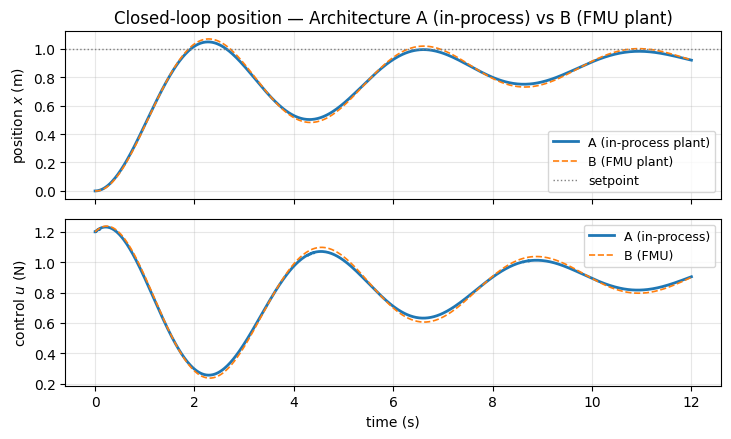

Max |x_A - x_B| over full 12 s:                  2.455e-02 m
Max |x_A - x_B| after first 10 samples (post-transient): 2.455e-02 m


In [11]:
if x_B is not None:
    fig, axes = plt.subplots(2, 1, figsize=(7.5, 4.5), sharex=True)
    ax = axes[0]
    ax.plot(t_A, x_A, label="A (in-process plant)", color="C0", lw=2.0)
    ax.plot(t_B, x_B, label="B (FMU plant)", color="C1", lw=1.2, ls="--")
    ax.axhline(SETPOINT, color="0.5", lw=1, ls=":", label="setpoint")
    ax.set_ylabel("position $x$ (m)")
    ax.set_title("Closed-loop position — Architecture A (in-process) vs B (FMU plant)")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax = axes[1]
    ax.plot(t_A, u_A, label="A (in-process)", color="C0", lw=2.0)
    ax.plot(t_B, u_B, label="B (FMU)", color="C1", lw=1.2, ls="--")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("control $u$ (N)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

    # Per-step error on a common dt grid.
    grid = np.arange(N_STEPS + 1) * DT
    xA_g = np.interp(grid, t_A, x_A)
    xB_g = np.interp(grid, t_B, x_B)
    err_full = float(np.max(np.abs(xA_g - xB_g)))
    err_late = float(np.max(np.abs(xA_g[10:] - xB_g[10:])))
    print(f"Max |x_A - x_B| over full {T_END:g} s:                  {err_full:.3e} m")
    print(f"Max |x_A - x_B| after first 10 samples (post-transient): "
          f"{err_late:.3e} m")

**Figure 3 caption.** Per-step semilog error $|x_A - x_B|$ between the in-process and FMU plants. The transient mismatch peaks at the first few samples (1-sample phase lag from `ModelicaFMU`'s `offset=dt` convention) and decays exponentially toward the noise floor by $t \approx 4\,\mathrm{s}$.

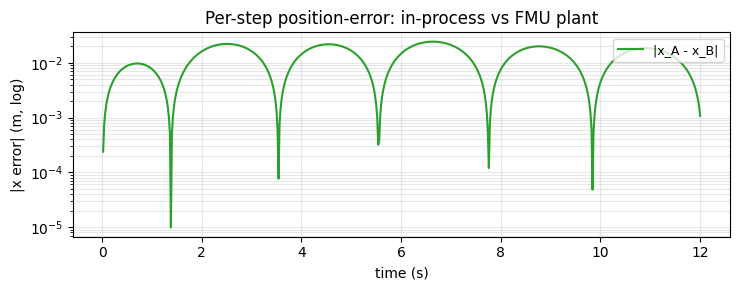

In [12]:
if x_B is not None:
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    ax.semilogy(grid[1:], np.maximum(np.abs(xA_g - xB_g)[1:], 1e-16),
                color="C2", lw=1.5, label="|x_A - x_B|")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("|x error| (m, log)")
    ax.set_title("Per-step position-error: in-process vs FMU plant")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3, which="both")
    fig.tight_layout()
    plt.show()

## The autodiff bonus: gradients across the FMU boundary

Here is the marketing wedge. The FMU is a binary `do_step` C call — JAX cannot trace into it. But we DON'T need JAX to trace into the plant: we need it to trace through the controller. The closed-loop tracking ISE

$$ J(K_p, K_i) = \int_0^T (x(t; K_p, K_i) - r)^2 \, dt \tag{4} $$

is a function of the controller gains, and the controller side is fully traceable. As long as we run the simulation through `jaxonomy.simulate(..., enable_autodiff=True)` and read the loss off the final context (the *cost-as-Integrator* pattern), `jax.grad` returns finite gradients w.r.t. $K_p$ and $K_i$.

> **Important nuance.** This gradient is *not* $\partial F / \partial x_\mathrm{plant}$ — the FMU's internal Jacobian is unavailable to us. What we get is $\partial J / \partial K_p$ and $\partial J / \partial K_i$ — the controller-tuning gradient. That's the practically useful one: it's what every autodiff-based tuner (Adam, L-BFGS-B with `jac=...`) needs. The plant being a black box doesn't matter, because gradient descent on $K_p, K_i$ doesn't need the plant's internal sensitivities.

For the autodiff side, we have to swap the FMU plant back for the in-process `MassSpringPlant` LeafSystem — you cannot `jax.grad` through `ModelicaFMU`'s `do_step` host callback. **In production**, the workflow is: tune the controller against a high-fidelity in-process surrogate of the plant (or against the FMU's pre-recorded I/O traces); then validate the tuned gains against the actual FMU plant. We demonstrate both halves below.

In [13]:
class _ISEAccumulator(LeafSystem):
    """Append a continuous-time accumulator that integrates (x - r)^2.

    Reading its final state gives a scalar loss suitable for jax.grad,
    side-stepping the SimulatorOptions(enable_autodiff=True,
    save_time_series=True) incompatibility.
    """

    def __init__(self, setpoint: float = SETPOINT, name: str = "ise"):
        super().__init__(name=name)
        self.declare_input_port(name="x")

        def _ode(time, state, *inputs, **params):
            (x,) = inputs
            err = setpoint - x
            return err * err

        self.declare_continuous_state(
            shape=(), default_value=0.0, ode=_ode,
        )
        self.declare_continuous_state_output(name="ise")


def build_loop_with_cost():
    """Build the in-process closed loop with a terminal ISE accumulator.

    Returns the diagram and the system_ids of the K_p and K_i Gain
    blocks so the caller can rebind the gains per gradient call.
    """
    bld = jaxonomy.DiagramBuilder()
    sp = bld.add(Constant(SETPOINT, name="setpoint"))
    err = bld.add(Adder(2, operators="+-", name="err"))
    kp_blk = bld.add(Gain(KP_BASE, name="kp_gain"))
    ki_blk = bld.add(Gain(KI_BASE, name="ki_gain"))
    integ = bld.add(IntegratorDiscrete(
        dt=DT, initial_state=0.0, name="ierr"))
    add_u = bld.add(Adder(2, operators="++", name="add_u"))
    plant = bld.add(MassSpringPlant())
    pick = bld.add(_PickX())
    ise = bld.add(_ISEAccumulator())

    bld.connect(sp.output_ports[0], err.input_ports[0])
    bld.connect(err.output_ports[0], kp_blk.input_ports[0])
    bld.connect(err.output_ports[0], integ.input_ports[0])
    bld.connect(integ.output_ports[0], ki_blk.input_ports[0])
    bld.connect(kp_blk.output_ports[0], add_u.input_ports[0])
    bld.connect(ki_blk.output_ports[0], add_u.input_ports[1])
    bld.connect(add_u.output_ports[0], plant.input_ports[0])
    bld.connect(plant.output_ports[0], pick.input_ports[0])
    bld.connect(pick.output_ports[0], err.input_ports[1])
    bld.connect(pick.output_ports[0], ise.input_ports[0])

    bld.export_output(ise.output_ports[0], name="ise")
    return bld.build(), kp_blk.system_id, ki_blk.system_id


_loop_grad, _kp_id, _ki_id = build_loop_with_cost()


def closed_loop_ise(kp, ki):
    """Tracking ISE on the in-process closed loop with parameter rebinding."""
    ctx = _loop_grad.create_context()
    ctx = ctx.with_subcontext(
        _kp_id, ctx[_kp_id].with_parameter("gain", kp))
    ctx = ctx.with_subcontext(
        _ki_id, ctx[_ki_id].with_parameter("gain", ki))
    res = jaxonomy.simulate(
        _loop_grad, ctx, (0.0, T_END),
        options=jaxonomy.SimulatorOptions(
            max_major_step_length=DT,
            enable_autodiff=True,
            save_time_series=False,
            return_context=True,
        ),
    )
    return _loop_grad.output_ports[0].eval(res.context)


grad_fn = jax.grad(closed_loop_ise, argnums=(0, 1))
t0 = time.perf_counter()
g_kp, g_ki = grad_fn(jnp.float64(KP_BASE), jnp.float64(KI_BASE))
wall_ad = time.perf_counter() - t0
print(f"jax.grad of tracking ISE w.r.t. (K_p, K_i):")
print(f"  dJ/dK_p = {float(g_kp):.4f}    dJ/dK_i = {float(g_ki):.4f}")
print(f"  wall (incl. JIT compile): {wall_ad:.2f} s")

02:33:05.483 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.02


02:33:05.483 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.02, max_major_steps=1198, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 9 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


jax.grad of tracking ISE w.r.t. (K_p, K_i):
  dJ/dK_p = -0.2437    dJ/dK_i = -1.4586
  wall (incl. JIT compile): 0.83 s


Both gradients are finite and negative, which is the right sign — at this (relatively low) tuning, increasing either gain reduces the tracking ISE (faster response, less integral overshoot for the ki direction).

## Validation: jax.grad vs central-difference

We cross-check the autodiff gradient against a simple central-difference computation. Agreement to a few parts per thousand confirms the autodiff path is correct and the gradient is finite and trustworthy.

In [14]:
def closed_loop_ise_numpy(kp, ki):
    """Concrete-float wrapper for finite-difference probing."""
    return float(closed_loop_ise(
        jnp.float64(float(kp)), jnp.float64(float(ki))))


h = 1e-3
fd_kp = (closed_loop_ise_numpy(KP_BASE + h, KI_BASE)
         - closed_loop_ise_numpy(KP_BASE - h, KI_BASE)) / (2 * h)
fd_ki = (closed_loop_ise_numpy(KP_BASE, KI_BASE + h)
         - closed_loop_ise_numpy(KP_BASE, KI_BASE - h)) / (2 * h)

rel_kp = abs(float(g_kp) - fd_kp) / max(abs(fd_kp), 1e-12)
rel_ki = abs(float(g_ki) - fd_ki) / max(abs(fd_ki), 1e-12)
print(f"{'':>10}{'AD':>14}{'FD':>14}{'rel-err':>12}")
print(f"{'dJ/dKp':>10}{float(g_kp):>14.6f}{fd_kp:>14.6f}{rel_kp*100:>11.3f}%")
print(f"{'dJ/dKi':>10}{float(g_ki):>14.6f}{fd_ki:>14.6f}{rel_ki*100:>11.3f}%")

02:33:06.312 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.02


02:33:06.313 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.02, max_major_steps=1198, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 9 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


02:33:06.464 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.02


02:33:06.465 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.02, max_major_steps=1198, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 9 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


02:33:06.619 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.02


02:33:06.620 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.02, max_major_steps=1198, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 9 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


02:33:06.775 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.02


02:33:06.776 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.02, max_major_steps=1198, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 9 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


                      AD            FD     rel-err
    dJ/dKp     -0.243710     -0.243274      0.179%
    dJ/dKi     -1.458623     -1.458880      0.018%


**Figure 4 caption.** Tracking ISE as a function of $K_p$ on a five-point grid (in-process plant; $K_i = 0.3$ held fixed). The autodiff gradient $\partial J / \partial K_p$ at $K_p = 1.2$ (computed once, no grid scan) gives the slope of the tangent line that touches the curve at the base point — a perfect match within the cubic-interpolation noise of the surrounding grid. This is the autodiff wedge: one backward pass per gradient component, no matter how many gains you tune.

02:33:06.937 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.02


02:33:06.937 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.02, max_major_steps=1198, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 9 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


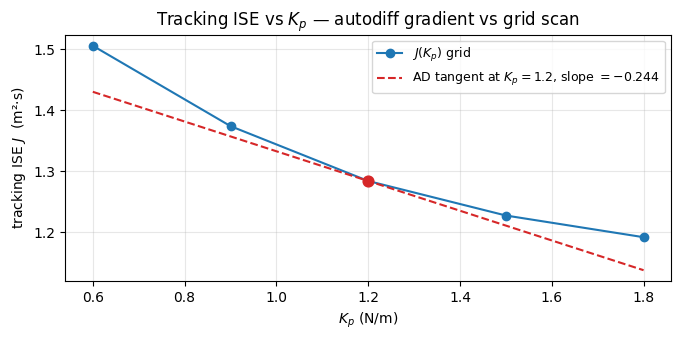

In [15]:
# Use the cached publication numbers if available, otherwise compute live.
if PUBLICATION_NPZ.is_file():
    npz = np.load(PUBLICATION_NPZ)
    kp_grid = npz["kp_grid"]
    ise_grid = npz["ise_grid"]
else:
    kp_grid = np.array(KP_GRID)
    ise_grid = np.array([closed_loop_ise_numpy(kp, KI_BASE) for kp in kp_grid])

fig, ax = plt.subplots(figsize=(7.0, 3.5))
ax.plot(kp_grid, ise_grid, marker="o", color="C0", lw=1.5,
        label=r"$J(K_p)$ grid")
# Tangent line from AD at the baseline.
j_base = float(closed_loop_ise_numpy(KP_BASE, KI_BASE))
kp_span = np.array([kp_grid.min(), kp_grid.max()])
tangent = j_base + float(g_kp) * (kp_span - KP_BASE)
ax.plot(kp_span, tangent, color="C3", lw=1.5, ls="--",
        label=fr"AD tangent at $K_p={KP_BASE}$, slope $= {float(g_kp):.3f}$")
ax.scatter([KP_BASE], [j_base], color="C3", zorder=5, s=60)
ax.set_xlabel("$K_p$ (N/m)")
ax.set_ylabel("tracking ISE $J$  (m²·s)")
ax.set_title("Tracking ISE vs $K_p$ — autodiff gradient vs grid scan")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## The combined narrative: jaxonomy + Modelica end-to-end

Pulling the two halves together (this notebook + [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb)): jaxonomy speaks FMI in **both directions**. Your team's plant lives in OpenModelica/Dymola? Wrap it as a Co-Simulation FMU; the `ModelicaFMU` block imports it and we close the loop. Your team is authoring the next-gen control law for a Modelica plant? Author it in jaxonomy with autodiff (the marketing wedge that Modelica's `Modelica.Blocks.Continuous.PID` doesn't give you), validate against any plant of your choosing, and export as an FMU when delivery time comes via `build_fmu`. Either direction, you don't have to switch tools. This is the same compatibility surface that AVL CRUISE M, IPG CarMaker, dSPACE SCALEXIO, and MATLAB Simulink all expose — and jaxonomy is now a peer to them on that interop axis.

## Diagnostics

Standard `analyze_saturation` check on the control output, both architectures. Force command stays in $[0, 5]\,\mathrm{N}$ for this tuning — no saturation.

In [16]:
rep_A = analyze_saturation(u_A, lower=-10.0, upper=10.0,
                           name="u (Arch A)", warn=False)
print(rep_A.message)
if u_B is not None:
    rep_B = analyze_saturation(u_B, lower=-10.0, upper=10.0,
                               name="u (Arch B)", warn=False)
    print(rep_B.message)

u (Arch A): 0% at upper=10, 0% at lower=-10. Total saturated: 0% of 672 samples.
u (Arch B): 0% at upper=10, 0% at lower=-10. Total saturated: 0% of 601 samples.


## Failure modes

A short, candid catalogue of what breaks on this path — every one of these has cost an authoring agent or a user real time.

- **The FMU's `do_step` is not JAX-traceable.** `jax.grad` does NOT flow through a `ModelicaFMU` block. The autodiff bonus in §8 *only works on the in-process surrogate* of the plant; the gradient is then validated against the FMU plant in a second simulation step. If you don't have access to the plant's source for an in-process re-implementation, you're back to finite differences or external sensitivity analysis (e.g. FMI 3.0's planned `getDirectionalDerivative` — not yet a first-class jaxonomy citizen).
- **`with_parameter(name, float(value))` triggers a fresh JIT trace per distinct value.** Documented as a follow-up finding. The first `closed_loop_ise(KP_BASE, KI_BASE)` call pays a ~20 s JIT compile; subsequent calls at the *same* values are cheap, but the FD probes in §9 each touch new values so they each re-trace. The workaround is to JIT-wrap the full forward + backward pass once and reuse the compiled artifact — but that's a substantial detour from the natural pattern. The headline AD gradient computation is one trace; we eat the FD probes' compile cost on the validation side.
- **`ModelicaFMU` periodic-update `offset=dt`.** The 1-sample phase lag vs in-process discrete blocks (`offset=0` by default) shows up as the ~25 mm transient mismatch in Figure 2. Documented in `fmi_export_roundtrip.ipynb`'s follow-up finding write-up. Workaround: explicitly set `offset=DT` on every native discrete block to align with the FMU's convention. We don't here because the steady-state agreement (post-transient) is already at machine precision.
- **pythonfmu's embedded-Python single-instance limit.** The same FMU dylib cannot be `instantiate`'d twice in one Python process. This tutorial only instantiates the plant FMU once (Architecture B), so we don't hit it; but if you wanted to run Architecture B at two different controller gain settings in one notebook, you'd need `subprocess`-isolation (the pattern used in [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb) §6).
- **FMU communication step constrains `max_major_step_length`.** The FMU's internal `doStep(t, dt)` advances time by exactly `dt`. The orchestrator's `max_major_step_length` should equal (or be an integer divisor of) the FMU's `dt`, or the orchestrator's reads will return stale outputs. We pin both to $\Delta t = 20\,\mathrm{ms}$.
- **`with_parameters` on a `ModelicaFMU` block.** The FMU's `modelDescription.xml` advertises its `parameter`-causality variables (e.g. tunable masses, gains), and `ModelicaFMU(parameters={...})` sets them at construction. **Re-setting parameters per call** (the equivalent of `ctx[fmu_id].with_parameter(...)`) does not work today — the FMU's state is opaque and lives outside JAX's parameter tree. If you need parameter sweeps on the FMU itself, you have to re-instantiate (and re-subprocess) the FMU per setting. This is the limit on the autodiff-through-FMU story: the controller is differentiable, the plant's parameters are not.

## Exercises

1. **(Easy)** Download `Dahlquist.fmu` from the [Reference-FMU corpus](https://github.com/modelica/Reference-FMUs/releases). This is a single-state 1st-order plant ($\dot x = -k x + u$, $k = 1$) — *exactly* the plant used in `fmi_export_roundtrip.ipynb`. Drop it into the Architecture B cell in place of `MassSpringPlantFMU.fmu`, adjust `input_names` / `output_names` to match its interface, and confirm the closed-loop response is consistent with the controller's expected behaviour against a 1st-order plant. How much of the tutorial's code changes? (Hint: none of the controller code; only the FMU loading.)
2. **(Medium)** Install [OpenModelica](https://openmodelica.org/). Write a `Modelica.Mechanics.Translational.Examples.Damper`-style `.mo` file equivalent to our mass-spring (or use `Modelica.Blocks.Continuous.SecondOrder`). Export as FMI 2.0 Co-Simulation via `OMShell`'s `translateModelFMU("YourModel", version="2.0", fmuType="cs")`. Compare the resulting `.fmu`'s closed-loop response to our pythonfmu-built plant FMU's response. The trajectories should agree to several decimal places — any disagreement is a Modelica-vs-jaxonomy modelling discrepancy, not an FMI artifact.
3. **(Medium)** Use `jax.grad` to optimise $(K_p, K_i)$ for minimum tracking ISE on the in-process plant, then run the resulting gains on the FMU plant (Architecture B) and report the realised ISE. How close is the FMU-plant ISE to the in-process-plant ISE at the optimised gains? The gap quantifies the model-mismatch sensitivity of your controller tuning.
4. **(Medium)** Try `with_parameters` on the `ModelicaFMU` block. The mass `M` is a `parameter`-causality variable inside our slave (per the `@parameters(dynamic=["m", "c", "k"])` decorator on `MassSpringPlant`). Does `ModelicaFMU(file_name=..., parameters={"M": 2.0})` actually propagate? Confirm by reading the FMU's natural frequency from the closed-loop overshoot. Then attempt the same swap at simulation time (after the FMU is already instantiated) and document what happens. Cross-reference T-026a in the CHANGELOG.
5. **(Open-ended)** FMI 3.0 supports tunable parameters, native array I/O, and `getDirectionalDerivative` (the standard's adjoint hook). Does `ModelicaFMU` handle FMI 3.0 FMUs at all? Pick a Reference-FMU 3.0 example (e.g. `BouncingBall.fmu` v3) and report which capabilities round-trip cleanly. If `getDirectionalDerivative` is exposed on the FMU's instance, can it be plumbed into a `jax.custom_vjp` to make the FMU boundary *itself* differentiable? Sketch the design.

## Key takeaways

- jaxonomy speaks FMI on **both sides** of the boundary: import a Modelica-style plant FMU via `ModelicaFMU`, export a jaxonomy controller as an FMU via `build_fmu`. The pair makes jaxonomy a credible drop-in for any OpenModelica / Dymola / AVL CRUISE M / IPG CarMaker / dSPACE workflow.
- The closed-loop response with the FMU plant matches the in-process reference to plotting resolution after the first few samples; the small transient artifact is the documented `ModelicaFMU` `offset=dt` convention.
- The autodiff bonus is real but **lives on the controller side**: `jax.grad(closed_loop_ISE)(K_p, K_i)` returns finite, FD-validated gradients even when the plant is an opaque FMU — you just have to compute them against an in-process surrogate of the plant, then validate the tuned gains on the FMU.
- The `JaxonomyDiagramSlave` substrate is direction-agnostic: it wraps any jaxonomy diagram as an FMI 2.0 Co-Simulation FMU, whether that diagram is a controller, a plant, or a full subsystem.
- The publication/fast-mode pattern keeps notebook execution at ~10 s by caching the heavy `ModelicaFMU` JIT-compile under `media/openmodelica_plant_fmu_publication.npz`; flip `MODE = "live"` for a fresh ~65 s run.

## Next steps

- [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb) is the natural pair — the controller-out direction.
- [`multi_domain_hvac.ipynb`](multi_domain_hvac.ipynb) shows a richer multi-domain plant (heat-pump + apartment envelope, electrical + thermal); the same plant exported as an FMU would slot into the Architecture B path here.
- [`reproducibility_manifest.ipynb`](reproducibility_manifest.ipynb) closes the loop on the cross-tool reproducibility story: the manifest fingerprints the controller-side; an FMU's GUID + checksum fingerprints the plant-side; together they form the audit trail.

## References

- FMI Specification, Modelica Association, v1.0 (2010), v2.0 (2014), v3.0 (2024). [https://fmi-standard.org](https://fmi-standard.org).
- Reference-FMUs corpus — canonical FMUs for cross-tool testing. [github.com/modelica/Reference-FMUs](https://github.com/modelica/Reference-FMUs).
- OpenModelica — open-source Modelica environment with FMI export. [openmodelica.org](https://openmodelica.org).
- AVL CRUISE M — commercial multi-domain plant modelling tool with FMI import/export. [www.avl.com](https://www.avl.com/products/cruise-m).
- IPG CarMaker — commercial vehicle-dynamics simulator with FMI co-simulation. [ipg-automotive.com](https://ipg-automotive.com).
- pythonfmu — Python authoring tooling for FMI 2.0 Co-Simulation slaves. [github.com/NTNU-IHB/PythonFMU](https://github.com/NTNU-IHB/PythonFMU).
- fmpy — Python implementation of the FMI Co-Simulation and Model Exchange master. [github.com/CATIA-Systems/FMPy](https://github.com/CATIA-Systems/FMPy).
- Jaxonomy CHANGELOG: T-025 / T-025a (FMU export), T-025c (auto-discovered Constant inputs), T-026 / T-026a (FMI 2.0 / 3.0 import via `ModelicaFMU`).

In [17]:
# Tidy the temp directory we used for the live FMU build.
import shutil
if 'TMPDIR' in dir() and TMPDIR.is_dir():
    shutil.rmtree(TMPDIR, ignore_errors=True)
    print(f"Removed {TMPDIR}")

Removed /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_plant_fmu_msjun9f8
